In [35]:
# ============================================================
# Importações
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

----------------

#### Importando a base de dados

In [36]:
df = pd.read_csv(r"C:\Users\pedro\Downloads\Base NPS Tratada.csv")

In [37]:
df.head()

,Unnamed: 0,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,...,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,categoria_nps,atraso_faixa,contatos_faixa
0,0,1,63,Nordeste,14,50001,139.73,4,39.35,4,...,3,0,4,6.9,0,3,6.5,Detrator,1-2 dias,0 contatos
1,1,2,20,Sul,1,50002,458.95,2,9.51,10,...,3,0,10,2.4,0,3,0.0,Detrator,3-5 dias,0 contatos
2,2,3,46,Nordeste,111,50003,507.06,5,42.82,6,...,1,4,5,4.8,0,7,1.5,Detrator,1-2 dias,4-5 contatos
3,3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,...,3,1,11,5.9,0,4,0.3,Detrator,1-2 dias,1 contato
4,4,5,56,Norte,50,50005,253.06,1,29.37,11,...,1,1,0,6.1,0,3,7.9,Detrator,1-2 dias,1 contato


####
--------------

#### Preparação dos dados


Vamos realizar categorização da variável de NPS entre clientes satisfeitos (neutros e promotores) e insatisfeitos (detratores)

In [38]:
# PREPARAÇÃO DAS VARIÁVEIS DE ENTRADA (X) E ALVO (y)
# ============================================================

# Colunas EXCLUÍDAS:
# customer_id, order_id - identificadores sem valor preditivo
# nps_score - resposta que queremos prever
# nps_categoria - derivada do nps_score, seria data leakage
# csat_internal_score - risco de ter sido coletado junto com o NPS
# atraso_faixa, contatos_faixa - colunas auxiliares criadas na EDA
# repeat_purchase_30d - causalidade invertida: recompra é consequência de NPS alto, não causa. Data leakage.
# customer_region - a média de NPS entre as regiões é muito próxima, não há poder explicativo que justifique adicionar ao modelo

FEATURES = [
    'customer_age',
    'customer_tenure_months',
    'order_value',
    'items_quantity',
    'discount_value',
    'payment_installments',
    'delivery_time_days',
    'delivery_delay_days',
    'freight_value',
    'delivery_attempts',
    'customer_service_contacts',
    'resolution_time_days',
    'complaints_count',
]

TARGET = 'nps_score'

X = df[FEATURES]
y = df[TARGET]

print(f'\nVariáveis de entrada ({len(FEATURES)}): {FEATURES}')
print(f'\nShape de X: {X.shape} | Shape de y: {y.shape}')


Variáveis de entrada (13): ['customer_age', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'complaints_count']

Shape de X: (2500, 13) | Shape de y: (2500,)


In [39]:
# SEPARAÇÃO TREINO/TESTE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

print(f'Treino: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:  {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.0f}%)')

Treino: 2,000 registros (80%)
Teste:  500 registros (20%)


In [40]:
# TREINAMENTO DO MODELO DE REGRESSÃO LINEAR MÚLTIPLA
# ============================================================

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print(f'   Intercepto: {modelo.intercept_:.4f}')
print(f'   Número de coeficientes aprendidos: {len(modelo.coef_)}')

   Intercepto: 9.2101
   Número de coeficientes aprendidos: 13


In [41]:
# COEFICIENTES DO MODELO
# ============================================================

coef_df = pd.DataFrame({
    'Variável':FEATURES,
    'Coeficiente':modelo.coef_
}).sort_values('Coeficiente', ascending = False)

print('Coeficientes do modelo (impacto no NPS por unidade da variável):')
print(coef_df.to_string(index=False))

Coeficientes do modelo (impacto no NPS por unidade da variável):
                 Variável  Coeficiente
        delivery_attempts     0.116175
     payment_installments     0.012284
           items_quantity     0.011224
       delivery_time_days     0.008105
             customer_age     0.000431
              order_value     0.000406
           discount_value    -0.001511
   customer_tenure_months    -0.001629
            freight_value    -0.008552
     resolution_time_days    -0.148197
customer_service_contacts    -0.341910
         complaints_count    -0.380133
      delivery_delay_days    -0.944231


In [42]:
# AVALIAÇÃO DO MODELO NO CONJUNTO DE TESTE
# ============================================================

# Gerando as previsões para os dados de teste

y_pred = modelo.predict(X_test)

# Métricas de avaliação
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print()
print('AVALIAÇÃO DO MODELO — CONJUNTO DE TESTE')
print()
print(f'MAE  (Erro Médio Absoluto):  {mae:.4f}')
print(f'RMSE (Raiz do Erro Quadrático Médio): {rmse:.4f}')
print(f'R²   (Coeficiente de Determinação):   {r2:.4f}')
print()
print('Interpretando:')
print(f'   → O modelo erra em média {mae:.2f} pontos na nota NPS')
print(f'   → O R² de {r2:.2%} significa que o modelo explica {r2:.0%} da')
print(f'     variação do NPS usando apenas dados operacionais')


AVALIAÇÃO DO MODELO — CONJUNTO DE TESTE

MAE  (Erro Médio Absoluto):  1.3382
RMSE (Raiz do Erro Quadrático Médio): 1.6902
R²   (Coeficiente de Determinação):   0.5479

Interpretando:
   → O modelo erra em média 1.34 pontos na nota NPS
   → O R² de 54.79% significa que o modelo explica 55% da
     variação do NPS usando apenas dados operacionais


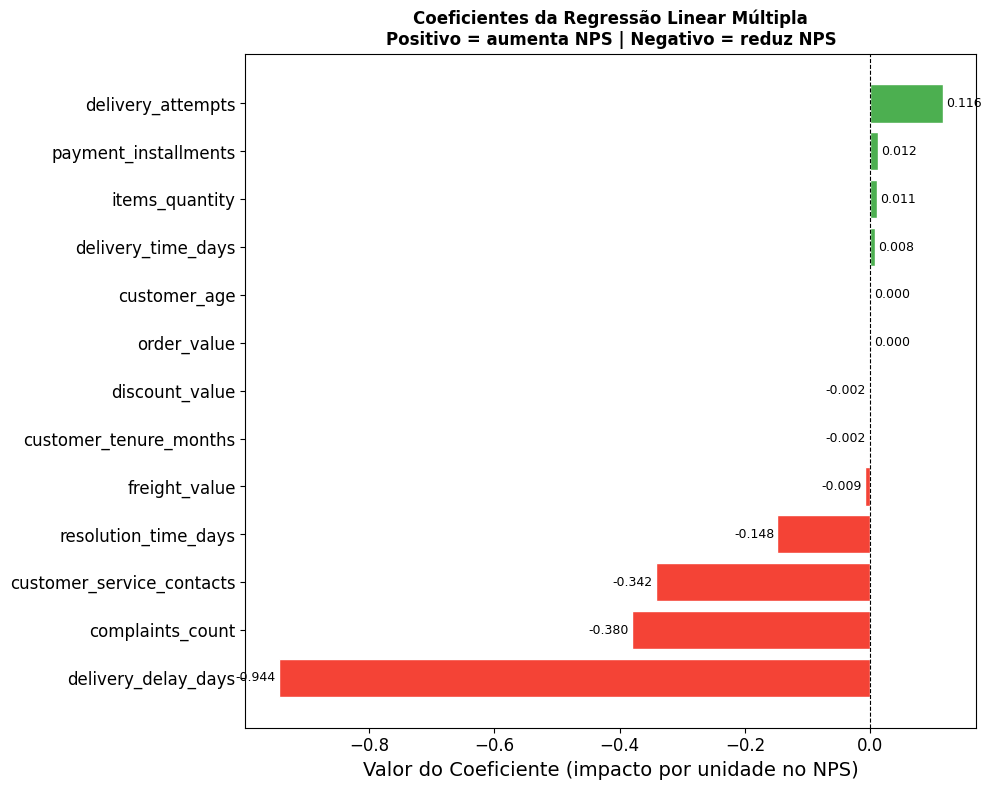

In [43]:
# PLOT DOS COEFICIENTES DO MODELO
# ============================================================


coef_plot = coef_df.sort_values('Coeficiente')
colors = ['#F44336' if v < 0 else '#4CAF50' for v in coef_plot['Coeficiente']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(coef_plot['Variável'], coef_plot['Coeficiente'],
               color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

for bar, val in zip(bars, coef_plot['Coeficiente']):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9)

ax.set_title('Coeficientes da Regressão Linear Múltipla\n'
             'Positivo = aumenta NPS | Negativo = reduz NPS',
             fontweight='bold')
ax.set_xlabel('Valor do Coeficiente (impacto por unidade no NPS)')
plt.tight_layout()
plt.show()

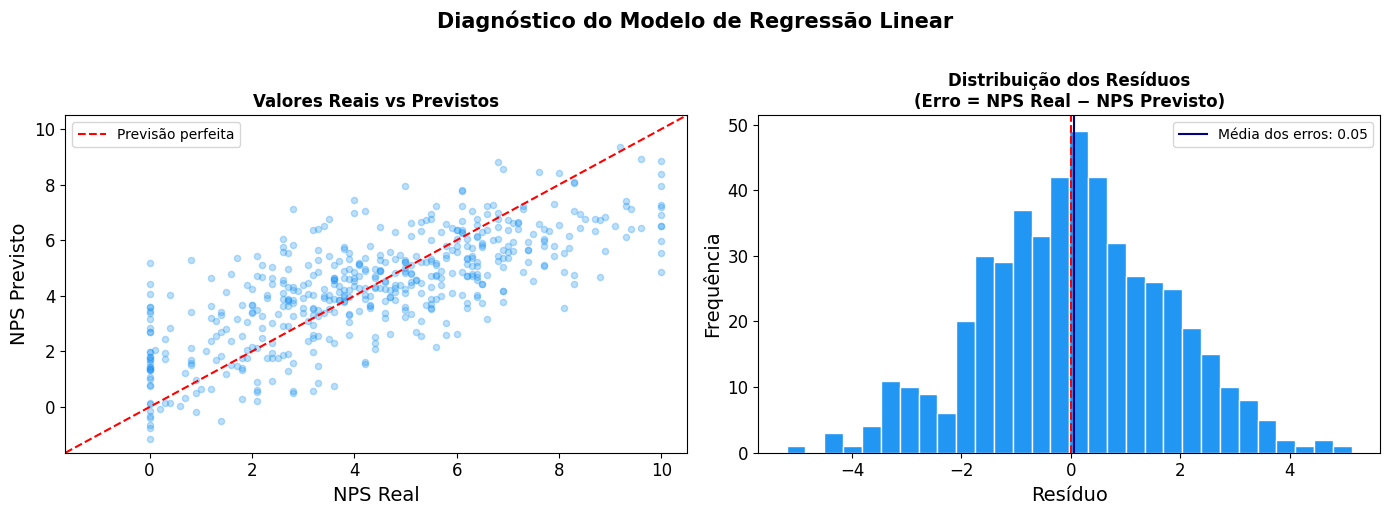

In [44]:
# PLOTANDO VALORES REAIS VS PREVISTOS
# ============================================================
# Um bom modelo tem os pontos alinhados na diagonal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: real vs previsto
axes[0].scatter(y_test, y_pred, alpha=0.3, color='#2196F3', s=20)
lim = [min(y_test.min(), y_pred.min()) - 0.5,
       max(y_test.max(), y_pred.max()) + 0.5]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Previsão perfeita')
axes[0].set_title('Valores Reais vs Previstos', fontweight='bold')
axes[0].set_xlabel('NPS Real')
axes[0].set_ylabel('NPS Previsto')
axes[0].legend()
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)

# Histograma dos resíduos (erros)
# Resíduos = diferença entre valor real e valor previsto
# Num bom modelo eles devem ser distribuídos em torno de 0
residuos = y_test - y_pred
axes[1].hist(residuos, bins=30, color='#2196F3', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(residuos.mean(), color='navy', linestyle='-', linewidth=1.5,
                label=f'Média dos erros: {residuos.mean():.2f}')
axes[1].set_title('Distribuição dos Resíduos\n(Erro = NPS Real − NPS Previsto)',
                  fontweight='bold')
axes[1].set_xlabel('Resíduo')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.suptitle('Diagnóstico do Modelo de Regressão Linear', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### 📋 Conclusões e Recomendações de Negócio

#### O que o modelo nos diz?

A regressão linear múltipla confirma o que a EDA sinalizou: **os fatores logísticos e de atendimento são os maiores determinantes do NPS**. Os coeficientes negativos mais intensos tipicamente pertencem a variáveis como `delivery_delay_days`, `complaints_count` e `customer_service_contacts`.

### 🎯 Recomendações para o negócio

| Prioridade | Ação | Área |
|---|---|---|
| **Alta** | Implementar alertas automáticos de SLA para pedidos próximos do prazo limite | Logística |
| **Alta** | Usar o modelo para acionamento proativo de CX em pedidos com previsão de NPS baixo | Atendimento |
| **Média** | Revisar política de frete para regiões com NPS mais baixo | Pricing |
| **Média** | Programa de fidelidade focado em clientes com menos de 12 meses | CRM |

### ⚠️ Limitações da regressão linear

1. **Linearidade:** o modelo assume que o impacto de cada variável é constante e linear — na realidade, um atraso de 1 dia pode não ter o mesmo efeito que um atraso de 10 dias.
2. **Sensibilidade a outliers:** valores extremos nas variáveis podem distorcer os coeficientes.
3. **Não captura interações:** o efeito combinado de atraso + reclamações + muitos contatos pode ser pior do que a soma das partes — a regressão linear simples não captura isso.
4. **R² limitado:** parte da variação do NPS é explicada por fatores subjetivos (humor do cliente, expectativa) que não estão nos dados operacionais.

---